# Laboratory 5 instruction part 2 - MLflow

In machine learning development, one of the most challenging aspects is maintaining reproducibility. This issue is particularly relevant to the experimental phase, when a lot of small, but influential code changes are constantly introduced.

After extensive experimentation with different model architectures, hyperparameters, and preprocessing techniques, researchers often find themselves unable to recreate their best-performing models because critical configuration details were not properly recorded.

## MLflow

[MLflow is an open-source platform](https://mlflow.org/) that addresses this challenge by providing systematic experiment tracking throughout the machine learning lifecycle. It automatically captures configurations, metrics, and artifacts from each model training run, transforming ad-hoc model development into a structured, reproducible process. In this notebook, we will learn how to use MLflow to properly track experiments for both traditional machine learning and deep learning workflows.


### Laboratory plan

1. **MLflow tracking server** configuration and deployment for experiment management
2. **Automatic logging mechanisms** for scikit-learn experiments
3. **Manual logging implementation** for PyTorch deep learning workflows
4. **Hyperparameter optimization exercise** - systematic hyperparameter exploration
5. **Best practices** for experiment organization, versioning, and cross-team reproducibility


## 1. MLflow Tracking server configuration

[MLflow Tracking](https://mlflow.org/docs/latest/tracking/) is the main component of MLflow, responsible for capturing, storing, and presenting metrics, logs, and other tracking data. MLflow is based on a client-server architecture, where the central MLflow server can serve potentially whole teams of data scientists. You can also simply run it as a local server from the commandline, as we will now.

You have two options for running MLflow:

#### Option 1: Local MLflow (Simple)
1. Open terminal - we recommend to split it into 2 shells or just open additional session.

1. Create a directory for MLflow artifacts storage:
```bash
mkdir mlflow-artifacts
```

2. Start the MLflow tracking server:
```bash
mlflow server \
  --backend-store-uri sqlite:///mlflow.db \
  --default-artifact-root ./mlflow-artifacts \
  --host 0.0.0.0 \
  --port 5001
```


**Important: Keep this terminal window open.** The MLflow server will continue running and be accessible at http://localhost:5001

#### Option 2: MLflow with Docker (Recommended for production-like setup)

1. Create a `docker-compose.yml` file:
```yaml
services:
  mlflow:
    image: ghcr.io/mlflow/mlflow:v2.9.2
    container_name: mlflow-server
    ports:
      - "5001:5000"
    volumes:
      - ./mlflow-data:/mlflow
    command:
      - mlflow
      - server
      - --backend-store-uri
      - sqlite:////mlflow/mlflow.db
      - --default-artifact-root
      - /mlflow/artifacts
      - --host
      - 0.0.0.0
      - --port
      - "5000"
    restart: unless-stopped
```

2. Start MLflow with Docker:
```bash
docker compose down -v
rm -rf mlflow-data
mkdir -p mlflow-data/artifacts
docker compose up -d
```

3. Check if it's running:
```bash
docker-compose ps
```

4. View logs (optional):
```bash
docker-compose logs -f mlflow
```

5. To stop the server later:
```bash
docker-compose down
```

**Important: Add MLflow files to .gitignore**

MLflow creates local files that should not be committed to Git. Add these lines to your `.gitignore`:

```
# MLflow
mlflow.db
mlflow-artifacts/
mlruns/
```

These files contain experiment data and artifacts that are specific to your local machine. In production, you would use a remote tracking server and artifact storage (like S3).

### Connecting to MLflow

To verify if the server runs properly, let's connect to it:

```python
import mlflow
import mlflow.sklearn

import warnings

warnings.filterwarnings("ignore")

mlflow.set_tracking_uri("http://localhost:5001")
print(f"Connected to MLflow at: {mlflow.get_tracking_uri()}")
```

**To stop the MLflow server later:**

- **Local setup**: Press `Ctrl+C` in the terminal where it's running
- **Docker setup**: Run `docker-compose down`

The server will shut down gracefully and save all your experiments.

**Note:** Keep the server running throughout this lab session. All your experiments will be logged to this server instance.


>>> import mlflow
>>> import mlflow.sklearn
>>> import warnings
>>> warnings.filterwarnings("ignore")
>>>
>>> mlflow.set_tracking_uri("http://localhost:5001")
>>> print(f"Connected to MLflow at: {mlflow.get_tracking_uri()}")
Connected to MLflow at: http://localhost:5001

In [1]:
import mlflow
import mlflow.sklearn

import warnings

from sklearn.isotonic import IsotonicRegression
from sklearn.naive_bayes import GaussianNB

warnings.filterwarnings("ignore")

mlflow.set_tracking_uri("http://localhost:5001")
print(f"Connected to MLflow at: {mlflow.get_tracking_uri()}")

Connected to MLflow at: http://localhost:5001


## 2. Automatic logging with scikit-learn

### 2.1 Dataset preparation

In this section, we'll use the Ames Housing dataset to demonstrate MLflow's autologging capabilities with scikit-learn. Since we have already prepared the 2006-2008 data using DVC, we can use our preprocessed dataset here. 

In [2]:
import numpy as np
import pandas as pd

from feature_engine.encoding import RareLabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

In [3]:
df = pd.read_parquet("data/ames_data_2006_2008.parquet")

df = df.sort_values(by=["Yr.Sold"])

# As we have temporal data, the best way to evaluate our model is time (chronological) 
# split, where the newest data is used for testing. We will assume that we have the 
# data #for years 2006 and 2007, and evaluate using data from 2008.

df_train = df[df["Yr.Sold"] < 2008]
df_test = df[df["Yr.Sold"] == 2008]

y_train = df_train.pop("SalePrice")
y_test = df_test.pop("SalePrice")

categorical_features = df_train.select_dtypes(include="object").columns
numerical_features = df_train.select_dtypes(exclude="object").columns

In [4]:
median_imputer = SimpleImputer(strategy="median")
min_max_scaler = MinMaxScaler()
rare_encoder = RareLabelEncoder(tol=0.01, n_categories=0, missing_values='ignore')
one_hot_encoder = OneHotEncoder(
    drop="first", sparse_output=False, handle_unknown="ignore"
)

num_pipeline = Pipeline(
    [("median_imputer", median_imputer), ("min_max_scaler", min_max_scaler)]
)

cat_pipeline = Pipeline(
    [("rare_encoder", rare_encoder), ("one_hot_encoder", one_hot_encoder)]
)

column_transformer = ColumnTransformer(
    [
        ("num_pipeline", num_pipeline, numerical_features),
        ("cat_pipeline", cat_pipeline, categorical_features),
    ],
    verbose_feature_names_out=False,
)
column_transformer.fit(df_train)

X_train = column_transformer.transform(df_train)
X_test = column_transformer.transform(df_test)

In [5]:
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Number of features: {X_train.shape[1]}")

Training samples: 1319
Test samples: 622
Number of features: 209


### 2.2 Training with MLflow autologging

Autologging is a powerful built-in capability of MLflow, enabling fully automated and near-zero code integration of MLflow with many popular frameworks. In particular, it works really well with scikit-learn, thanks to its highly unified API. Let's try this out - we will enable autologging, and then train a bunch of different models.

In [6]:
mlflow.sklearn.autolog(
    log_input_examples=True, log_model_signatures=True, log_models=False, silent=False
)

mlflow.set_experiment("ames-housing-autolog")

2026/03/25 21:52:04 WARNING mlflow.utils.autologging_utils: MLflow sklearn autologging is known to be compatible with 0.24.1 <= scikit-learn <= 1.6.1, but the installed version is 1.7.0. If you encounter errors during autologging, try upgrading / downgrading scikit-learn to a compatible version, or try upgrading MLflow.


<Experiment: artifact_location='/Users/bartoszkordek/PycharmProjects/MLOps_course_lab5/mlflow-artifacts/1', creation_time=1773786913510, experiment_id='1', last_update_time=1773786913510, lifecycle_stage='active', name='ames-housing-autolog', tags={}>

In [7]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, MultiTaskLasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

models = [
    ("Ridge Regression", Ridge()),
    ("Decision Tree", DecisionTreeRegressor(max_depth=10, random_state=42)),
    ("K-Nearest Neighbors", KNeighborsRegressor(n_neighbors=10)),
    ("Random Forest", RandomForestRegressor(n_estimators=100, random_state=42)),
    ("Gradient Boosting", GradientBoostingRegressor(n_estimators=100, random_state=42)),
]

In [8]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

def fit_sklearn_models_with_cv(models, X_train, X_test, y_train, y_test):
    results = {}

    for model_name, model in models:

        # start MLflow run - a unit grouping logs from different model runs
        # everything within this context manager will get logged as a run
        with mlflow.start_run(run_name=model_name):
            mlflow.log_param("dvc_data_md5", dvc_metadata.get("md5"))

            model.fit(X_train, y_train)

            y_pred = model.predict(X_test)

            rmse = root_mean_squared_error(y_test, y_pred)
            mae = mean_absolute_error(y_test, y_pred)
            r2 = r2_score(y_test, y_pred)

            cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring="r2")
            cv_mean = cv_scores.mean()
            cv_std = cv_scores.std()
            
            # log additional custom metrics, in addition to autologging
            mlflow.log_metric("cv_r2_mean", cv_mean)
            mlflow.log_metric("cv_r2_std", cv_std)

            results[model_name] = {
                "rmse": rmse,
                "mae": mae,
                "r2": r2,
                "cv_r2_mean": cv_mean,
            }

            print(f"\n{model_name}:")
            print(f"  RMSE: {rmse:.2f}")
            print(f"  MAE: {mae:.2f}")
            print(f"  R^2: {r2:.3f}")
            print(f"  CV R^2 (mean ± std): {cv_mean:.3f} ± {cv_std:.3f}")

In [11]:
fit_sklearn_models_with_cv(models, X_train, X_test, y_train, y_test)

2026/03/25 21:52:38 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/25 21:52:39 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/25 21:52:39 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/25 21:52:39 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/25 21:52:39 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/25 21:52:39 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/25 21:52:39 WARNING mlflow.sklearn: Failed t


Ridge Regression:
  RMSE: 31348.39
  MAE: 17303.38
  R^2: 0.828
  CV R^2 (mean ± std): 0.841 ± 0.067
🏃 View run Ridge Regression at: http://localhost:5001/#/experiments/1/runs/3499865d16a8413198f3452597b44666
🧪 View experiment at: http://localhost:5001/#/experiments/1


2026/03/25 21:52:39 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/25 21:52:39 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/25 21:52:39 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/25 21:52:39 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'



Decision Tree:
  RMSE: 42569.32
  MAE: 25638.53
  R^2: 0.682
  CV R^2 (mean ± std): 0.737 ± 0.086
🏃 View run Decision Tree at: http://localhost:5001/#/experiments/1/runs/2fbad361f3d44da499550d228cf30705
🧪 View experiment at: http://localhost:5001/#/experiments/1


2026/03/25 21:52:40 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/25 21:52:40 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/25 21:52:40 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/25 21:52:40 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/25 21:52:40 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/25 21:52:40 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'



K-Nearest Neighbors:
  RMSE: 37972.33
  MAE: 25638.13
  R^2: 0.747
  CV R^2 (mean ± std): 0.685 ± 0.065
🏃 View run K-Nearest Neighbors at: http://localhost:5001/#/experiments/1/runs/bfa141a1d4af4739b4feef7b819cc921
🧪 View experiment at: http://localhost:5001/#/experiments/1


2026/03/25 21:52:42 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/25 21:52:43 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/25 21:52:44 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/25 21:52:46 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/25 21:52:47 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/25 21:52:48 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'



Random Forest:
  RMSE: 26415.08
  MAE: 15952.25
  R^2: 0.878
  CV R^2 (mean ± std): 0.853 ± 0.062
🏃 View run Random Forest at: http://localhost:5001/#/experiments/1/runs/c63e499d5cf34c689b9a6b2dd3c92b1f
🧪 View experiment at: http://localhost:5001/#/experiments/1


2026/03/25 21:52:49 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/25 21:52:49 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/25 21:52:50 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/25 21:52:50 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/25 21:52:51 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'



Gradient Boosting:
  RMSE: 24001.89
  MAE: 15253.71
  R^2: 0.899
  CV R^2 (mean ± std): 0.863 ± 0.070
🏃 View run Gradient Boosting at: http://localhost:5001/#/experiments/1/runs/bc4e8329ad2e42edb5b2042d92433e53
🧪 View experiment at: http://localhost:5001/#/experiments/1


Open the MLflow dashboard at http://localhost:5001/ and go to the Experiments tab. On the left, you have the experiment name, and when you select it, the list of all experiments will show up. Click through the interface and familiarize yourself with the most important elements:

1. What columns can be selected
2. Pick a particular run and check what values are logged automatically
3. Select columns to compare a given metric between runs, e.g. MAE
4. Sort algorithms by the selected metric to pick the best one

![Training with MLflow autologging_main.png](screenshots/Training%20with%20MLflow%20autologging_main.png)

### 1. Selected columns

![Training with MLflow autologging_selected_columns.png](screenshots/Training%20with%20MLflow%20autologging_selected_columns.png)

### 2. Pick a particular run and check what values are logged automatically

![Training with MLflow autologging_RandomForest_description.png](screenshots/Training%20with%20MLflow%20autologging_RandomForest_description.png)

![Training with MLflow autologging_RandomForest_parameters.png](screenshots/Training%20with%20MLflow%20autologging_RandomForest_parameters.png)

### 3. Select columns to compare a given metric between runs, e.g. MAE


![Training with MLflow autologging_mae.png](screenshots/Training%20with%20MLflow%20autologging_mae.png)

### 4. Sort algorithms by the selected metric to pick the best one

The lowest MAE

![Training with MLflow autologging_best_mae.png](screenshots/Training%20with%20MLflow%20autologging_best_mae.png)

## 2.3 Connecting DVC and MLflow

You've already used DVC to version your dataset in the first part of this lab. Now let's connect DVC metadata with MLflow experiments to create a complete audit trail. When you run experiments, you want to know:
- Which version of the data was used?
- Can I reproduce these exact results?
- What changed between experiments?

By logging DVC metadata in MLflow, you create a link between your data versions and experiment results.

### Reading DVC metadata

DVC stores metadata in `.dvc` files. Let's read it:

In [10]:
import yaml

def get_dvc_metadata(dvc_file_path):
    with open(dvc_file_path, 'r') as f:
        dvc_data = yaml.safe_load(f)
    
    metadata = {
        'md5': dvc_data['outs'][0]['md5'],
        'size': dvc_data['outs'][0]['size'],
        'path': dvc_data['outs'][0]['path']
    }
    return metadata

dvc_metadata = get_dvc_metadata('data/ames_data_2006_2008.parquet.dvc')
print("DVC Metadata:")
print(f"MD5 hash: {dvc_metadata['md5']}")
print(f"File size: {dvc_metadata['size']} bytes")
print(f"Data path: {dvc_metadata['path']}")

DVC Metadata:
MD5 hash: f44053333f88a0646819936b37f000ee
File size: 162560 bytes
Data path: ames_data_2006_2008.parquet


### Exercise 1 - Logging DVC metadata in MLflow

We have trained 5 different models. The results of all of them can now be compared in MLflow. Now let's modify our training to include DVC metadata. This creates a complete audit trail:
- **Git commit** → tracks code version
- **DVC hash** → tracks data version
- **MLflow run** → tracks experiment results

Your task is to:
1. Run 5 more experiments with different parameters and models from scikit-learn. You can use any [supervised learning methods from scikit-learn](https://scikit-learn.org/stable/supervised_learning.html). Find some other models or parameters to tune our current models with and run the experiments again. 
2. Use the function `fit_sklearn_models_with_cv()` created above, or you can write your own if you want.
3. Make sure you have included DVC metadata logging. You can initialize dvc_metadata by calling above defined `get_dvc_metadata` function with the .dvc metadata file. Then you can just for each experiment add param logging like:

```python
mlflow.log_param("param_name", "value you want to log") # e.g md5
```

In [9]:
from sklearn.linear_model import Lasso, LassoLars, BayesianRidge, HuberRegressor, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, AdaBoostRegressor

In [13]:
additional_models = [
    ("Lasso_alpha_0.1", Lasso(alpha=0.1)),
    ("Lasso_alpha_1.0", Lasso(alpha=1.0)),
    ("BayesianRidge", BayesianRidge()),
    ("Ridge_alpha_1.0", Ridge(alpha=1.0)),
    ("Ridge_alpha_10.0", Ridge(alpha=10.0)),
    ("Huber", HuberRegressor(max_iter=1000)),
    ("ElasticNet", ElasticNet(alpha=0.1)),
    ("Decision_Tree_depth_5", DecisionTreeRegressor(max_depth=5)),
    ("Decision_Tree_depth_10", DecisionTreeRegressor(max_depth=10)),
    ("Hist_Gradient_Boosting", HistGradientBoostingRegressor(max_iter=100)),
    ("Ada_Boost", AdaBoostRegressor(n_estimators=100)),
    ("LARS_Lasso", LassoLars(alpha=.1)),
]

In [14]:
fit_sklearn_models_with_cv(additional_models, X_train, X_test, y_train, y_test)

2026/03/24 00:57:13 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/24 00:57:13 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/24 00:57:13 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/24 00:57:13 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/24 00:57:13 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/24 00:57:13 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/24 00:57:14 WARNING mlflow.sklearn: Failed t


Lasso_alpha_0.1:
  RMSE: 33626.15
  MAE: 17581.67
  R^2: 0.802
  CV R^2 (mean ± std): 0.784 ± 0.090
🏃 View run Lasso_alpha_0.1 at: http://localhost:5001/#/experiments/1/runs/5834f33103674bceab64b1e6a393add0
🧪 View experiment at: http://localhost:5001/#/experiments/1


2026/03/24 00:57:14 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/24 00:57:14 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/24 00:57:14 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/24 00:57:14 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/24 00:57:14 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/24 00:57:14 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/24 00:57:15 WARNING mlflow.sklearn: Failed t


Lasso_alpha_1.0:
  RMSE: 33672.02
  MAE: 17482.65
  R^2: 0.801
  CV R^2 (mean ± std): 0.782 ± 0.086
🏃 View run Lasso_alpha_1.0 at: http://localhost:5001/#/experiments/1/runs/0f8908059fd04bf79c67ec5938d59914
🧪 View experiment at: http://localhost:5001/#/experiments/1


2026/03/24 00:57:15 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/24 00:57:15 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/24 00:57:15 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/24 00:57:16 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/24 00:57:16 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'


...


Hist_Gradient_Boosting:
  RMSE: 25703.15
  MAE: 15088.53
  R^2: 0.884
  CV R^2 (mean ± std): 0.858 ± 0.055
🏃 View run Hist_Gradient_Boosting at: http://localhost:5001/#/experiments/1/runs/3f27f43a91024eab821d8215e5f6acdc
🧪 View experiment at: http://localhost:5001/#/experiments/1


2026/03/24 00:57:27 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/24 00:57:28 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/24 00:57:28 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/24 00:57:29 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/24 00:57:29 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/24 00:57:30 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/24 00:57:30 WARNING mlflow.sklearn: Failed t


Ada_Boost:
  RMSE: 33919.07
  MAE: 25656.29
  R^2: 0.798
  CV R^2 (mean ± std): 0.779 ± 0.083
🏃 View run Ada_Boost at: http://localhost:5001/#/experiments/1/runs/98b5e6e351504b7d99fc27bf37e01458
🧪 View experiment at: http://localhost:5001/#/experiments/1


2026/03/24 00:57:30 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/24 00:57:30 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/03/24 00:57:30 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'



LARS_Lasso:
  RMSE: 119366079568782864.00
  MAE: 6768629395683287.00
  R^2: -2497471321552954280902656.000
  CV R^2 (mean ± std): 0.837 ± 0.075
🏃 View run LARS_Lasso at: http://localhost:5001/#/experiments/1/runs/024a291cb3fa4dc7a8d630550fea0ceb
🧪 View experiment at: http://localhost:5001/#/experiments/1


![Additional_models_results.png](screenshots/Additional_models_results.png)

## 3. Manual logging with PyTorch

In this section, we'll implement manual logging for PyTorch models. While scikit-learn has autologging, PyTorch requires manual tracking - giving us full control over what and when to log. MLflow supports autologging for [PyTorch Lightning](https://lightning.ai/docs/pytorch/stable/), but we often need low-level control of pure PyTorch.

Note that we need to turn off scikit-learn autologging! Since we are using a Jupyter Notebook, MLflow uses the previously configured autologging unless explicitly turned off.

In [15]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import KFold

# disable sklearn autologging!
mlflow.sklearn.autolog(disable=True)

mlflow.set_experiment("pytorch-housing-manual")

<Experiment: artifact_location='/Users/bartoszkordek/PycharmProjects/MLOps_course_lab5/mlflow-artifacts/2', creation_time=1773794544428, experiment_id='2', last_update_time=1773794544428, lifecycle_stage='active', name='pytorch-housing-manual', tags={}>

### 3.1 Targets transformation

Before training the neural network, we will transform the training target, in order to stabilize the training. To see why, let's plot the house prices:

<Axes: ylabel='Frequency'>

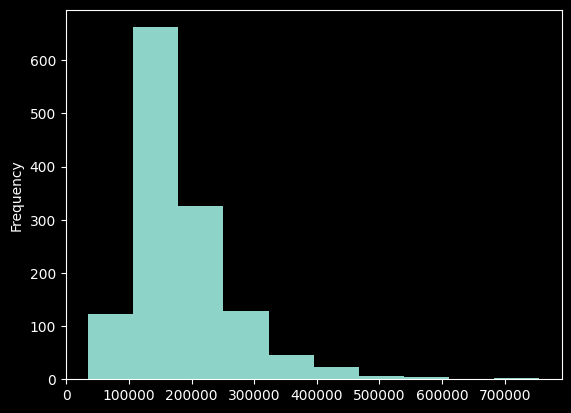

In [16]:
y_train.plot.hist()

Training on such targets is possible, but very large target values easily risk overflow, particularly when a loss function like mean squared error is used. We will use the log-transform to transform this distribution, as it's near-exponential, so it should bring it closer to normal, and also greatly reduce the values range.

Of course, we will need to transform the network predictions back again to evaluate them.

<Axes: ylabel='Frequency'>

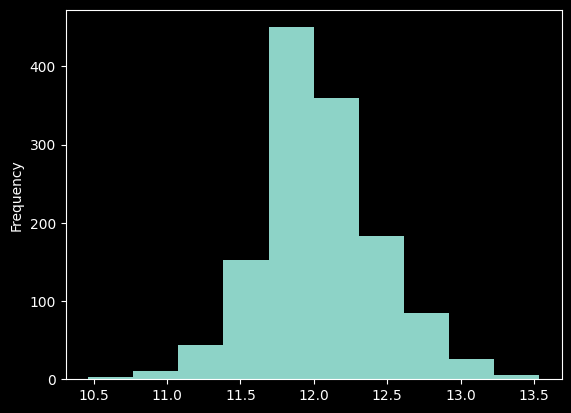

In [18]:
y_train_log = np.log1p(y_train)

pd.Series(y_train_log).plot.hist()

### 3.2 Define and train the model

Since we have tabular data, we will use a simple 2-layer multilayer perceptron (MLP).

In [19]:
class HousePriceNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, dropout_rate=0.2):
        super(HousePriceNet, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

For training, we will check both the 5-fold CV performance, and the traditional train-test split. Cross-validation will give us an additional, robust performance estimation, as well as standard deviation, which is useful for comparing performances of different models. After all, if the difference between models would be within one standard deviation, it wouldn't really be meaningful.


In [20]:
import torch.nn as nn


class PyTorchTrainer:
    def __init__(
        self, model_class: type[nn.Module], config: dict
    ):
        required_keys = ['hidden_units', 'dropout', 'batch_size', 'learning_rate', 
                         'log_interval', 'epochs', 'name']
        missing = [key for key in required_keys if key not in config]
        if missing:
            raise ValueError(f"Missing required config keys: {missing}")
        
        self.model_class = model_class
        self.config = config

    def create_model(self, input_dim: int) -> nn.Module:
        return self.model_class(
            input_dim=input_dim,
            hidden_dim=self.config["hidden_units"],
            dropout_rate=self.config["dropout"],
        )

    def create_data_loader(
        self, X: torch.Tensor, y: torch.Tensor, shuffle: bool = True
    ) -> DataLoader:
        dataset = TensorDataset(X, y)
        return DataLoader(
            dataset, batch_size=self.config["batch_size"], shuffle=shuffle
        )

    def train_epoch(
        self,
        model: nn.Module,
        train_loader: DataLoader,
        criterion: nn.Module,
        optimizer: optim.Optimizer,
    ) -> float:
        model.train()
        epoch_loss = 0.0
        batch_count = 0

        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            batch_count += 1

        return epoch_loss / batch_count

    def train_model(
        self,
        model: nn.Module,
        train_loader: DataLoader,
        epochs: int,
        metric_prefix: str = "",
    ) -> None:
        criterion = nn.MSELoss()
        optimizer = optim.Adam(model.parameters(), lr=self.config["learning_rate"])

        for epoch in range(epochs):
            avg_mse = self.train_epoch(model, train_loader, criterion, optimizer)

            if epoch % self.config["log_interval"] == 0:
                metric_name = (
                    f"{metric_prefix}train_mse" if metric_prefix else "train_mse"
                )
                # manually log metric value, with a given name and step value
                mlflow.log_metric(metric_name, avg_mse, step=epoch)

    @torch.no_grad()
    def evaluate_model(
        self,
        model: nn.Module,
        X: torch.Tensor,
        y_test: torch.Tensor,
        log_prefix: str = "",
    ) -> dict[str, float]:
        model.eval()
        
        y_pred_norm = model(X)

        # revert the logarithm with exponent
        y_pred = np.expm1(y_pred_norm.numpy())
        y_test = y_test.numpy()

        rmse = root_mean_squared_error(y_test.ravel(), y_pred.ravel())
        mae = mean_absolute_error(y_test.ravel(), y_pred.ravel())
        r2 = r2_score(y_test.ravel(), y_pred.ravel())

        if log_prefix:
            # manually log metrics that we want
            mlflow.log_metric(f"{log_prefix}_rmse", rmse)
            mlflow.log_metric(f"{log_prefix}_mae", mae)
            mlflow.log_metric(f"{log_prefix}_r2", r2)

        return {"rmse": rmse, "mae": mae, "r2": r2}

    def run_cross_validation(
        self, X_train: torch.Tensor, y_train: torch.Tensor, n_splits: int = 5
    ) -> tuple[float, float, list[float]]:
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
        cv_scores = []

        for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
            print(f"\nTraining Fold {fold + 1}/{n_splits}...")

            X_fold_train = X_train[train_idx]
            y_fold_train = y_train[train_idx]
            X_fold_val = X_train[val_idx]
            y_fold_val = y_train[val_idx]

            fold_model = self.create_model(X_train.shape[1])
            fold_loader = self.create_data_loader(X_fold_train, y_fold_train)

            self.train_model(
                fold_model,
                fold_loader,
                self.config["epochs"],
                metric_prefix=f"fold_{fold + 1}_",
            )

            # transform validation data with exponent back to original unit
            y_fold_val = np.expm1(y_fold_val)
            
            val_metrics = self.evaluate_model(
                fold_model, X_fold_val, y_fold_val, log_prefix=f"fold_{fold + 1}_val"
            )

            cv_scores.append(val_metrics["r2"])
            print(
                f"  Fold {fold + 1} "
                f"Validation - RMSE: {val_metrics['rmse']:.2f}, "
                f"MAE: {val_metrics['mae']:.2f} "
                f"R^2: {val_metrics['r2']:.3f}"
            )

        return np.mean(cv_scores), np.std(cv_scores), cv_scores

    def _log_dvc_metadata(self, dvc_file_path: str = 'data/ames_data_2006_2008.parquet.dvc'):
        try:
            dvc_metadata = get_dvc_metadata(dvc_file_path)
            
            mlflow.log_param("data_dvc_md5", dvc_metadata['md5'])
            mlflow.log_param("data_dvc_size", dvc_metadata['size'])
            mlflow.log_param("data_path", dvc_metadata['path'])
            print(f"Logged DVC metadata: {dvc_metadata['md5'][:8]}...")
        except FileNotFoundError:
            print("DVC file not found - skipping metadata logging")
        except Exception as e:
            print(f"Could not log DVC metadata: {e}")

    def fit(
        self,
        X_train: pd.DataFrame | np.ndarray,
        y_train: pd.Series | np.ndarray,
        X_test: pd.DataFrame | np.ndarray,
        y_test: pd.Series | np.ndarray,
    ) -> dict:
        X_train, X_test, y_train, y_test = self._prepare_tensors(
            X_train, X_test, y_train, y_test
        )

        with mlflow.start_run(run_name=self.config["name"]):
            mlflow.log_params(self.config)
            
            # Log DVC metadata for data versioning
            self._log_dvc_metadata()

            print(f"Starting 5-fold cross-validation for {self.config['name']}...")
            cv_mean, cv_std, cv_scores = self.run_cross_validation(X_train, y_train)

            mlflow.log_metric("cv_r2_mean", cv_mean)
            mlflow.log_metric("cv_r2_std", cv_std)

            print(
                f"\nCross-validation complete. Mean R^2: {cv_mean:.3f} (+/- {cv_std:.3f})"
            )
            print("\nTraining final model on all training data...")

            final_model = self.create_model(X_train.shape[1])
            final_loader = self.create_data_loader(X_train, y_train)

            self.train_model(
                final_model,
                final_loader,
                self.config["epochs"],
                metric_prefix="final_model_",
            )

            print("\nEvaluating on test set...")
            test_metrics = self.evaluate_model(final_model, X_test, y_test)

            mlflow.log_metric("test_rmse", test_metrics["rmse"])
            mlflow.log_metric("test_mae", test_metrics["mae"])
            mlflow.log_metric("test_r2", test_metrics["r2"])

            self._print_results(test_metrics, cv_mean, cv_std)

            return {
                "rmse": test_metrics["rmse"],
                "mae": test_metrics["mae"],
                "r2": test_metrics["r2"],
                "cv_r2_mean": cv_mean,
                "cv_r2_std": cv_std,
                "cv_scores": cv_scores,
            }

    def _prepare_tensors(self, X_train, X_test, y_train, y_test) -> tuple:
        y_train = np.array(y_train)
        y_test = np.array(y_test)
        
        X_train_tensor = torch.FloatTensor(X_train)
        y_train_tensor = torch.FloatTensor(y_train.reshape(-1, 1))
        
        X_test_tensor = torch.FloatTensor(X_test)
        y_test_tensor = torch.FloatTensor(y_test.reshape(-1, 1))

        print(f"Training samples: {X_train_tensor.shape[0]}")
        print(f"Input features: {X_train_tensor.shape[1]}")
        
        return X_train_tensor, X_test_tensor, y_train_tensor, y_test_tensor
    
    def _print_results(
        self, test_metrics: dict[str, float], cv_mean: float, cv_std: float
    ) -> None:
        print(f"{'=' * 50}\n")
        print(f"  Mean R^2: {cv_mean:.3f} (+/- {cv_std:.3f})")
        print("\nCross-Validation Performance:")
        print(f"  R^2: {test_metrics['r2']:.3f}")
        print(f"  RMSE: {test_metrics['rmse']:.2f}")
        print(f"  MAE: {test_metrics['mae']:.2f}")
        print("Test Set Performance:")
        print(f"{'=' * 50}")
        print(f"FINAL RESULTS for {self.config['name']}:")
        print(f"\n{'=' * 50}")

Quite a bit of code there! So now let's train the model.

### Configuration 
`base_config` contains **fixed parameters** that stay the same across all experiments:
- `model_class`: The neural network architecture we're using (HousePriceNet)
- `random_seed`: For reproducibility (42)
- `log_interval`: How often to log metrics during training (every 5 epochs)
- `num_samples`: Dataset size
- `input_features`: Number of input features
- `k_folds`: Number of cross-validation folds (5)

`experiment_config` contains **hyperparameters** we want to tune:
- `name`: Unique identifier for this experiment run
- `hidden_units`: Size of the hidden layer (128, 256, 512, etc.)
- `dropout`: Dropout rate for regularization (0.0 to 0.5)
- `learning_rate`: Step size for gradient descent (0.001 to 0.1)
- `epochs`: Number of training iterations (50, 100, 150, etc.)
- `batch_size`: Number of samples per training batch (16, 32, 64, etc.)

If you want you can deliver your own NeuralNetwork model, and just specify in experiment_config: `{"model_class": YourOwnModel}` it will overwrite the our base `HousePriceNet`


#### 3. Merging configurations
We use Python's dictionary merge operator `|` to combine them:
```python
training_config = base_config | experiment_config
```

This creates a single configuration dictionary with all parameters. The `experiment_config` values override any duplicate keys from `base_config`, allowing us to easily experiment with different hyperparameters while keeping the base setup constant.

Now let's set up our first experiment:


In [21]:
base_config = {
    "model_class": HousePriceNet,
    "random_seed": 42,
    "log_interval": 5,
    "num_samples": X_train.shape[0],
    "input_features": X_train.shape[1],
    "k_folds": 5,
}

experiment_config = {
    "name": "first_run",
    "hidden_units": 128,
    "dropout": 0.1,
    "learning_rate": 0.03,
    "epochs": 150,
    "batch_size": 32,
}

In [22]:
training_config = base_config | experiment_config

trainer = PyTorchTrainer(training_config["model_class"], training_config)
trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1319
Input features: 209
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for first_run...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 45887.96, MAE: 31505.71 R^2: 0.763

Training Fold 2/5...
  Fold 2 Validation - RMSE: 45488.02, MAE: 33051.43 R^2: 0.677

Training Fold 3/5...
  Fold 3 Validation - RMSE: 44405.21, MAE: 27862.10 R^2: 0.735

Training Fold 4/5...
  Fold 4 Validation - RMSE: 40238.88, MAE: 29107.54 R^2: 0.720

Training Fold 5/5...
  Fold 5 Validation - RMSE: 68874.59, MAE: 29947.75 R^2: 0.133

Cross-validation complete. Mean R^2: 0.606 (+/- 0.238)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.606 (+/- 0.238)

Cross-Validation Performance:
  R^2: 0.643
  RMSE: 45132.48
  MAE: 19131.90
Test Set Performance:
FINAL RESULTS for first_run:

🏃 View run first_run at: http://localhost:5001/#/experiments/2/runs/bf4f41cc235444b9aad649d8cf469a29
🧪 View experiment at: http://localhost:5001/#/experiments/2

{'rmse': 45132.484375,
 'mae': 19131.904296875,
 'r2': 0.6429598331451416,
 'cv_r2_mean': np.float64(0.6056980967521668),
 'cv_r2_std': np.float64(0.23774225125623077),
 'cv_scores': [0.7630815505981445,
  0.6768988370895386,
  0.7353383302688599,
  0.719671905040741,
  0.1334998607635498]}

![first_run.png](screenshots/first_run.png)

### Exercise 2

Your task is to:
1. Run 10 experiments by modifying the hyperparameter configuration. Try to improve model performance, which is currently overfitted.
2. Analyze results in MLflow UI.
3. Comment on what changes impacted the model performance the most, and what changes disrupted the training process.
4. Compare the results of our first scikit-learn configuration with the first PyTorch experiments. Do you see any overfitting in the first PyTorch experiment? Explain what signs of overfitting can indicate this situation.

**How to modify configurations:**

You have two approaches:

#### Approach 1: Loop through multiple configurations (Recommended for systematic exploration)

Define a list of experiment configurations and iterate through them. Each configuration dictionary should contain only the hyperparameters you want to tune (name, hidden_units, dropout, learning_rate, epochs, batch_size). The base_config stays the same.

```python
base_config = {
    "model_class": HousePriceNet,  
    "random_seed": 42,             
    "log_interval": 5,             
    "input_features": X_train.shape[1],  # Number of features (181)
    "num_samples": X_train.shape[0],     # Dataset size (1312)
    "target_normalized": True,      
    "k_folds": 5,                  
}

# Define multiple experiments to run
configs = [
    {
        "name": "baseline_128_units",
        "hidden_units": 128,
        "dropout": 0.1,
        "learning_rate": 0.03,
        "epochs": 150,
        "batch_size": 32,
    },
    {
        "name": "larger_network_256",
        "hidden_units": 256,        # Try larger network
        "dropout": 0.2,             # More dropout for regularization
        "learning_rate": 0.01,      # Lower learning rate
        "epochs": 200,
        "batch_size": 64,    
    },
    {
        "name": "high_regularization",
        "hidden_units": 128,
        "dropout": 0.3,             # Even more dropout
        "learning_rate": 0.01,
        "epochs": 150,
        "batch_size": 32,
    },
    # Add 7 more configurations here...
]

# Run all experiments
for experiment_config in configs:
    training_config = base_config | experiment_config 
    
    trainer = PyTorchTrainer(training_config["model_class"], training_config)
    results = trainer.fit(X_train, y_train_log, X_test, y_test)
```

#### Approach 2: Manual and incremental (Good for quick iterations)

Run experiments one by one, adjusting hyperparameters based on previous results:

```python
# First experiment
experiment_config = {
    "name": "experiment_01_baseline",
    "hidden_units": 128,
    "dropout": 0.1,
    "learning_rate": 0.03,
    "epochs": 150,
    "batch_size": 32,    
}

training_config = base_config | experiment_config 
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)
```
After analyzing results in MLflow, run another experiment

```
experiment_config = {
    "name": "experiment_02_more_dropout",
    "hidden_units": 128,
    "dropout": 0.3,  # Increased from 0.1
    "learning_rate": 0.03,
    "epochs": 150,
    "batch_size": 32,    
}

training_config = base_config | experiment_config 
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

# Continue with more experiments
```


**Tips for hyperparameter tuning:**
- Start with one change at a time to understand its impact
- Use meaningful experiment names that describe what you changed
- Check MLflow UI after each experiment to guide your next choice
- Look for signs of overfitting: high training performance but poor test performance
- Watch the training curves in MLflow's "Model metrics" tab 


### Lab assessment

Fill the code exercises in this Jupyter notebook, and send it with completed exercises, written comments in Markdown cells (particularly for questions in exercise 2), and screenshots of results in MLflow.


### Starting configuration

In [23]:
experiment_config = {
    "name": "exp01_dropout_03",
    "hidden_units": 128,
    "dropout": 0.3,
    "learning_rate": 0.03,
    "epochs": 150,
    "batch_size": 32,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1319
Input features: 209
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp01_dropout_03...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 36427.61, MAE: 23669.16 R^2: 0.851

Training Fold 2/5...
  Fold 2 Validation - RMSE: 26885.30, MAE: 16230.41 R^2: 0.887

Training Fold 3/5...
  Fold 3 Validation - RMSE: 57958.91, MAE: 23157.32 R^2: 0.549

Training Fold 4/5...
  Fold 4 Validation - RMSE: 30868.88, MAE: 21321.11 R^2: 0.835

Training Fold 5/5...
  Fold 5 Validation - RMSE: 59365.30, MAE: 20397.79 R^2: 0.356

Cross-validation complete. Mean R^2: 0.696 (+/- 0.208)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.696 (+/- 0.208)

Cross-Validation Performance:
  R^2: 0.493
  RMSE: 53774.96
  MAE: 22099.16
Test Set Performance:
FINAL RESULTS for exp01_dropout_03:

🏃 View run exp01_dropout_03 at: http://localhost:5001/#/experiments/2/runs/1ddf647a8fcc4c458f9f07cd875146ce
🧪 View experiment at: http://localhost

![exp01_dropout_03.png](screenshots/exp01_dropout_03.png)

![exp01_dropout_03_test_set.png](screenshots/exp01_dropout_03_test_set.png)

In [24]:
experiment_config = {
    "name": "exp01_a_dropout_03_learning_rate_015_epochs_200",
    "hidden_units": 128,
    "dropout": 0.3,
    "learning_rate": 0.015,
    "epochs": 200,
    "batch_size": 32,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1319
Input features: 209
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp01_a_dropout_03_learning_rate_015_epochs_200...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 29847.61, MAE: 18587.08 R^2: 0.900

Training Fold 2/5...
  Fold 2 Validation - RMSE: 23758.72, MAE: 15039.38 R^2: 0.912

Training Fold 3/5...
  Fold 3 Validation - RMSE: 44675.40, MAE: 21663.03 R^2: 0.732

Training Fold 4/5...
  Fold 4 Validation - RMSE: 25364.40, MAE: 17941.06 R^2: 0.889

Training Fold 5/5...
  Fold 5 Validation - RMSE: 49513.45, MAE: 18898.84 R^2: 0.552

Cross-validation complete. Mean R^2: 0.797 (+/- 0.139)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.797 (+/- 0.139)

Cross-Validation Performance:
  R^2: 0.706
  RMSE: 40973.79
  MAE: 21102.73
Test Set Performance:
FINAL RESULTS for exp01_a_dropout_03_learning_rate_015_epochs_200:

🏃 View run exp01_a_dropout_03_learning_rate_015_epochs_200 at: http://localhost:5001

![exp01_a_dropout_03_learning_rate_015_epochs_200.png](screenshots/exp01_a_dropout_03_learning_rate_015_epochs_200.png)

![exp01_a_dropout_03_learning_rate_015_epochs_200_test_set.png](screenshots/exp01_a_dropout_03_learning_rate_015_epochs_200_test_set.png)

In [25]:
experiment_config = {
    "name": "exp02_dropout_03_hidden_units_256",
    "hidden_units": 256,
    "dropout": 0.3,
    "learning_rate": 0.03,
    "epochs": 150,
    "batch_size": 32,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1319
Input features: 209
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp02_dropout_03_hidden_units_256...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 30086.62, MAE: 19719.23 R^2: 0.898

Training Fold 2/5...
  Fold 2 Validation - RMSE: 24104.34, MAE: 16715.25 R^2: 0.909

Training Fold 3/5...
  Fold 3 Validation - RMSE: 45610.37, MAE: 23555.34 R^2: 0.721

Training Fold 4/5...
  Fold 4 Validation - RMSE: 26476.65, MAE: 19853.27 R^2: 0.879

Training Fold 5/5...
  Fold 5 Validation - RMSE: 47439.70, MAE: 19071.92 R^2: 0.589

Cross-validation complete. Mean R^2: 0.799 (+/- 0.125)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.799 (+/- 0.125)

Cross-Validation Performance:
  R^2: 0.721
  RMSE: 39909.74
  MAE: 23453.32
Test Set Performance:
FINAL RESULTS for exp02_dropout_03_hidden_units_256:

🏃 View run exp02_dropout_03_hidden_units_256 at: http://localhost:5001/#/experiments/2/runs/0f6187fd9aa94140ab4c

![exp02_dropout_03_hidden_units_256.png](screenshots/exp02_dropout_03_hidden_units_256.png)

![exp02_dropout_03_hidden_units_256_test_set.png](screenshots/exp02_dropout_03_hidden_units_256_test_set.png)

In [49]:
experiment_config = {
    "name": "exp02_a_hidden_units_256_learning_rate_0005_epochs_300",
    "hidden_units": 256,
    "dropout": 0.3,
    "learning_rate": 0.005,
    "epochs": 300,
    "batch_size": 32,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1319
Input features: 209
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp02_a_hidden_units_256_learning_rate_0005_epochs_300...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 43423.45, MAE: 26353.16 R^2: 0.788

Training Fold 2/5...
  Fold 2 Validation - RMSE: 38860.96, MAE: 26904.78 R^2: 0.764

Training Fold 3/5...
  Fold 3 Validation - RMSE: 46264.28, MAE: 34417.80 R^2: 0.713

Training Fold 4/5...
  Fold 4 Validation - RMSE: 39279.22, MAE: 29361.47 R^2: 0.733

Training Fold 5/5...
  Fold 5 Validation - RMSE: 102061.61, MAE: 52586.73 R^2: -0.903

Cross-validation complete. Mean R^2: 0.419 (+/- 0.661)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.419 (+/- 0.661)

Cross-Validation Performance:
  R^2: 0.711
  RMSE: 40577.49
  MAE: 19387.20
Test Set Performance:
FINAL RESULTS for exp02_a_hidden_units_256_learning_rate_0005_epochs_300:

🏃 View run exp02_a_hidden_units_256_learning_rate_0005_epochs_300 at

![exp02_a_hidden_units_256_learning_rate_0005_epochs_300.png](screenshots/exp02_a_hidden_units_256_learning_rate_0005_epochs_300.png)

In [50]:
experiment_config = {
    "name": "exp02_hidden_units_64_dropout_02_learning_rate_0001_epochs_200_batch_size_64",
    "hidden_units": 64,
    "dropout": 0.2,
    "learning_rate": 0.001,
    "epochs": 200,
    "batch_size": 64,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1319
Input features: 209
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp02_hidden_units_64_dropout_02_learning_rate_0001_epochs_200_batch_size_64...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 71713.03, MAE: 42802.03 R^2: 0.421

Training Fold 2/5...
  Fold 2 Validation - RMSE: 67338.56, MAE: 48509.18 R^2: 0.292

Training Fold 3/5...
  Fold 3 Validation - RMSE: 93502.24, MAE: 46013.89 R^2: -0.173

Training Fold 4/5...
  Fold 4 Validation - RMSE: 53258.04, MAE: 38088.38 R^2: 0.509

Training Fold 5/5...
  Fold 5 Validation - RMSE: 59637.13, MAE: 40329.50 R^2: 0.350

Cross-validation complete. Mean R^2: 0.280 (+/- 0.238)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.280 (+/- 0.238)

Cross-Validation Performance:
  R^2: 0.198
  RMSE: 67647.49
  MAE: 39759.26
Test Set Performance:
FINAL RESULTS for exp02_hidden_units_64_dropout_02_learning_rate_0001_epochs_200_batch_size_64:

🏃 View run exp02_hidden_u

![exp02_hidden_units_64_dropout_02_learning_rate_0001_epochs_200_batch_size_64.png](screenshots/exp02_hidden_units_64_dropout_02_learning_rate_0001_epochs_200_batch_size_64.png)

In [26]:
experiment_config = {
    "name": "exp03_dropout_04_hidden_units_512",
    "hidden_units": 512,
    "dropout": 0.4,
    "learning_rate": 0.03,
    "epochs": 150,
    "batch_size": 32,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1319
Input features: 209
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp03_dropout_04_hidden_units_512...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 36176.63, MAE: 22544.13 R^2: 0.853

Training Fold 2/5...
  Fold 2 Validation - RMSE: 31105.65, MAE: 20210.44 R^2: 0.849

Training Fold 3/5...
  Fold 3 Validation - RMSE: 51441.39, MAE: 23056.53 R^2: 0.645

Training Fold 4/5...
  Fold 4 Validation - RMSE: 30698.28, MAE: 21773.21 R^2: 0.837

Training Fold 5/5...
  Fold 5 Validation - RMSE: 54005.13, MAE: 19075.86 R^2: 0.467

Cross-validation complete. Mean R^2: 0.730 (+/- 0.153)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.730 (+/- 0.153)

Cross-Validation Performance:
  R^2: 0.669
  RMSE: 43425.79
  MAE: 24064.59
Test Set Performance:
FINAL RESULTS for exp03_dropout_04_hidden_units_512:

🏃 View run exp03_dropout_04_hidden_units_512 at: http://localhost:5001/#/experiments/2/runs/7680266c988a4ffb923b

![exp03_dropout_04_hidden_units_512.png](screenshots/exp03_dropout_04_hidden_units_512.png)

In [30]:
experiment_config = {
    "name": "exp04_learning_rate_005",
    "hidden_units": 128,
    "dropout": 0.1,
    "learning_rate": 0.05,
    "epochs": 150,
    "batch_size": 32,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1319
Input features: 209
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp04_learning_rate_005...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 28823.97, MAE: 17652.25 R^2: 0.907

Training Fold 2/5...
  Fold 2 Validation - RMSE: 27118.74, MAE: 16675.66 R^2: 0.885

Training Fold 3/5...
  Fold 3 Validation - RMSE: 53107.31, MAE: 21218.34 R^2: 0.621

Training Fold 4/5...
  Fold 4 Validation - RMSE: 25256.92, MAE: 18183.55 R^2: 0.890

Training Fold 5/5...
  Fold 5 Validation - RMSE: 50331.89, MAE: 18342.15 R^2: 0.537

Cross-validation complete. Mean R^2: 0.768 (+/- 0.156)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.768 (+/- 0.156)

Cross-Validation Performance:
  R^2: 0.534
  RMSE: 51560.85
  MAE: 34454.33
Test Set Performance:
FINAL RESULTS for exp04_learning_rate_005:

🏃 View run exp04_learning_rate_005 at: http://localhost:5001/#/experiments/2/runs/7e152c8348cf448faffa8d5b4b64faba
🧪 View experiment

![exp04_learning_rate_005.png](screenshots/exp04_learning_rate_005.png)


In [32]:
experiment_config = {
    "name": "exp05_epochs_250",
    "hidden_units": 128,
    "dropout": 0.1,
    "learning_rate": 0.03,
    "epochs": 250,
    "batch_size": 32,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1319
Input features: 209
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp05_epochs_250...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 27561.86, MAE: 18560.00 R^2: 0.915

Training Fold 2/5...
  Fold 2 Validation - RMSE: 32153.70, MAE: 19141.84 R^2: 0.839

Training Fold 3/5...
  Fold 3 Validation - RMSE: 59185.25, MAE: 20876.97 R^2: 0.530

Training Fold 4/5...
  Fold 4 Validation - RMSE: 23178.96, MAE: 17129.87 R^2: 0.907

Training Fold 5/5...
  Fold 5 Validation - RMSE: 50005.40, MAE: 21184.69 R^2: 0.543

Cross-validation complete. Mean R^2: 0.747 (+/- 0.174)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.747 (+/- 0.174)

Cross-Validation Performance:
  R^2: 0.650
  RMSE: 44657.73
  MAE: 25032.18
Test Set Performance:
FINAL RESULTS for exp05_epochs_250:

🏃 View run exp05_epochs_250 at: http://localhost:5001/#/experiments/2/runs/ebf60b831d714e4888e143bc1f266a94
🧪 View experiment at: http://localhost

![exp05_epochs_250.png](screenshots/exp05_epochs_250.png)

In [33]:
experiment_config = {
    "name": "exp06_epochs_250_hidden_units_512_dropout_03_learning_rate_005",
    "hidden_units": 512,
    "dropout": 0.3,
    "learning_rate": 0.05,
    "epochs": 250,
    "batch_size": 32,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1319
Input features: 209
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp06_epochs_250_hidden_units_512_dropout_03_learning_rate_005...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 61056.81, MAE: 39348.62 R^2: 0.581

Training Fold 2/5...
  Fold 2 Validation - RMSE: 32814.71, MAE: 22303.01 R^2: 0.832

Training Fold 3/5...
  Fold 3 Validation - RMSE: 61196.76, MAE: 30971.92 R^2: 0.497

Training Fold 4/5...
  Fold 4 Validation - RMSE: 33233.10, MAE: 24659.72 R^2: 0.809

Training Fold 5/5...
  Fold 5 Validation - RMSE: 41839.38, MAE: 23793.02 R^2: 0.680

Cross-validation complete. Mean R^2: 0.680 (+/- 0.129)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.680 (+/- 0.129)

Cross-Validation Performance:
  R^2: 0.462
  RMSE: 55383.67
  MAE: 29730.35
Test Set Performance:
FINAL RESULTS for exp06_epochs_250_hidden_units_512_dropout_03_learning_rate_005:

🏃 View run exp06_epochs_250_hidden_units_512_dropout_0

![exp06_epochs_250_hidden_units_512_dropout_03_learning_rate_005.png](screenshots/exp06_epochs_250_hidden_units_512_dropout_03_learning_rate_005.png)

In [40]:
experiment_config = {
    "name": "exp07_epochs_100",
    "hidden_units": 128,
    "dropout": 0.1,
    "learning_rate": 0.03,
    "epochs": 100,
    "batch_size": 32,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1319
Input features: 209
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp07_epochs_100...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 55809.41, MAE: 37900.97 R^2: 0.650

Training Fold 2/5...
  Fold 2 Validation - RMSE: 72481.50, MAE: 46590.54 R^2: 0.180

Training Fold 3/5...
  Fold 3 Validation - RMSE: 72545.53, MAE: 50885.77 R^2: 0.294

Training Fold 4/5...
  Fold 4 Validation - RMSE: 57229.13, MAE: 41963.46 R^2: 0.433

Training Fold 5/5...
  Fold 5 Validation - RMSE: 88303.95, MAE: 76608.33 R^2: -0.424

Cross-validation complete. Mean R^2: 0.226 (+/- 0.361)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.226 (+/- 0.361)

Cross-Validation Performance:
  R^2: -0.340
  RMSE: 87438.49
  MAE: 48591.59
Test Set Performance:
FINAL RESULTS for exp07_epochs_100:

🏃 View run exp07_epochs_100 at: http://localhost:5001/#/experiments/2/runs/c9145827129841e29f4c837330ba2d6e
🧪 View experiment at: http://localho

![exp07_epochs_100](screenshots/exp07_epochs_100.png)


In [45]:
experiment_config = {
    "name": "exp08_learning_rate_001",
    "hidden_units": 128,
    "dropout": 0.1,
    "learning_rate": 0.01,
    "epochs": 150,
    "batch_size": 32,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1319
Input features: 209
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp08_learning_rate_001...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 72508.88, MAE: 53528.02 R^2: 0.408

Training Fold 2/5...
  Fold 2 Validation - RMSE: 40416.05, MAE: 28497.78 R^2: 0.745

Training Fold 3/5...
  Fold 3 Validation - RMSE: 126381.86, MAE: 91973.12 R^2: -1.144

Training Fold 4/5...
  Fold 4 Validation - RMSE: 44388.57, MAE: 34967.47 R^2: 0.659

Training Fold 5/5...
  Fold 5 Validation - RMSE: 100431.56, MAE: 59234.44 R^2: -0.842

Cross-validation complete. Mean R^2: -0.035 (+/- 0.796)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: -0.035 (+/- 0.796)

Cross-Validation Performance:
  R^2: 0.142
  RMSE: 69949.67
  MAE: 56050.98
Test Set Performance:
FINAL RESULTS for exp08_learning_rate_001:

🏃 View run exp08_learning_rate_001 at: http://localhost:5001/#/experiments/2/runs/bfef6705b5b843c393488f432c3b3520
🧪 View expe

![exp08_learning_rate_001](screenshots/exp08_learning_rate_001.png)

In [47]:
experiment_config = {
    "name": "exp09_learning_rate_001_hidden_units_256_dropout_03",
    "hidden_units": 256,
    "dropout": 0.3,
    "learning_rate": 0.01,
    "epochs": 150,
    "batch_size": 32,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1319
Input features: 209
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp09_learning_rate_001_hidden_units_256_dropout_03...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 116692.83, MAE: 93493.52 R^2: -0.532

Training Fold 2/5...
  Fold 2 Validation - RMSE: 78182.21, MAE: 66092.91 R^2: 0.046

Training Fold 3/5...
  Fold 3 Validation - RMSE: 86563.23, MAE: 68461.27 R^2: -0.006

Training Fold 4/5...
  Fold 4 Validation - RMSE: 77721.89, MAE: 64208.51 R^2: -0.046

Training Fold 5/5...
  Fold 5 Validation - RMSE: 71244.02, MAE: 54357.94 R^2: 0.073

Cross-validation complete. Mean R^2: -0.093 (+/- 0.223)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: -0.093 (+/- 0.223)

Cross-Validation Performance:
  R^2: 0.454
  RMSE: 55835.56
  MAE: 39014.55
Test Set Performance:
FINAL RESULTS for exp09_learning_rate_001_hidden_units_256_dropout_03:

🏃 View run exp09_learning_rate_001_hidden_units_256_dropout_03 at: htt

![exp09_learning_rate_001_hidden_units_256_dropout_03](screenshots/exp09_learning_rate_001_hidden_units_256_dropout_03.png)

In [48]:
experiment_config = {
    "name": "exp10_hidden_units_64",
    "hidden_units": 64,
    "dropout": 0.1,
    "learning_rate": 0.03,
    "epochs": 150,
    "batch_size": 32,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1319
Input features: 209
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp10_hidden_units_64...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 30073.92, MAE: 18107.01 R^2: 0.898

Training Fold 2/5...
  Fold 2 Validation - RMSE: 25513.18, MAE: 15849.79 R^2: 0.898

Training Fold 3/5...
  Fold 3 Validation - RMSE: 41769.64, MAE: 18581.89 R^2: 0.766

Training Fold 4/5...
  Fold 4 Validation - RMSE: 27977.91, MAE: 19725.66 R^2: 0.864

Training Fold 5/5...
  Fold 5 Validation - RMSE: 50871.83, MAE: 20238.96 R^2: 0.527

Cross-validation complete. Mean R^2: 0.791 (+/- 0.140)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.791 (+/- 0.140)

Cross-Validation Performance:
  R^2: 0.191
  RMSE: 67921.12
  MAE: 29538.10
Test Set Performance:
FINAL RESULTS for exp10_hidden_units_64:

🏃 View run exp10_hidden_units_64 at: http://localhost:5001/#/experiments/2/runs/43711ac3fdec487ca301b6afe0f77d9f
🧪 View experiment at: h

![exp10_hidden_units_64](screenshots/exp10_hidden_units_64.png)


In [61]:
experiment_config = {
    "name": "exp11_hidden_units_96_dropout_05_learning_rate_001_epochs_250_batch_size_64",
    "hidden_units": 96,
    "dropout": 0.5,
    "learning_rate": 0.01,
    "epochs": 250,
    "batch_size": 64,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1319
Input features: 209
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp11_hidden_units_96_dropout_05_learning_rate_001_epochs_250_batch_size_64...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 31106.85, MAE: 18320.07 R^2: 0.891

Training Fold 2/5...
  Fold 2 Validation - RMSE: 23349.23, MAE: 15970.69 R^2: 0.915

Training Fold 3/5...
  Fold 3 Validation - RMSE: 41713.50, MAE: 20855.44 R^2: 0.766

Training Fold 4/5...
  Fold 4 Validation - RMSE: 31058.00, MAE: 20978.34 R^2: 0.833

Training Fold 5/5...
  Fold 5 Validation - RMSE: 36266.51, MAE: 17911.46 R^2: 0.760

Cross-validation complete. Mean R^2: 0.833 (+/- 0.063)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.833 (+/- 0.063)

Cross-Validation Performance:
  R^2: 0.693
  RMSE: 41874.36
  MAE: 18424.30
Test Set Performance:
FINAL RESULTS for exp11_hidden_units_96_dropout_05_learning_rate_001_epochs_250_batch_size_64:

🏃 View run exp11_hidden_unit

![exp11_hidden_units_96_dropout_05_learning_rate_001_epochs_250_batch_size_64](screenshots/exp11_hidden_units_96_dropout_05_learning_rate_001_epochs_250_batch_size_64.png)

In [63]:
experiment_config = {
    "name": "exp11_a_hidden_units_96_dropout_06_learning_rate_0008_epochs_250_batch_size_64",
    "hidden_units": 96,
    "dropout": 0.6,
    "learning_rate": 0.008,
    "epochs": 250,
    "batch_size": 64,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1319
Input features: 209
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp11_a_hidden_units_96_dropout_06_learning_rate_0005_epochs_250_batch_size_64...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 43725.82, MAE: 25754.44 R^2: 0.785

Training Fold 2/5...
  Fold 2 Validation - RMSE: 27762.97, MAE: 17644.72 R^2: 0.880

Training Fold 3/5...
  Fold 3 Validation - RMSE: 43392.04, MAE: 22575.32 R^2: 0.747

Training Fold 4/5...
  Fold 4 Validation - RMSE: 32370.81, MAE: 22154.46 R^2: 0.819

Training Fold 5/5...
  Fold 5 Validation - RMSE: 37131.64, MAE: 22132.82 R^2: 0.748

Cross-validation complete. Mean R^2: 0.796 (+/- 0.050)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.796 (+/- 0.050)

Cross-Validation Performance:
  R^2: 0.714
  RMSE: 40421.47
  MAE: 18431.81
Test Set Performance:
FINAL RESULTS for exp11_a_hidden_units_96_dropout_06_learning_rate_0005_epochs_250_batch_size_64:

🏃 View run exp11_a_hid

![exp11_a_hidden_units_96_dropout_06_learning_rate_0005_epochs_250_batch_size_64](screenshots/exp11_a_hidden_units_96_dropout_06_learning_rate_0005_epochs_250_batch_size_64.png)

In [69]:
experiment_config = {
    "name": "exp11_b_hidden_units_64_dropout_06_learning_rate_01_epochs_250_batch_size_64",
    "hidden_units": 64,
    "dropout": 0.6,
    "learning_rate": 0.1,
    "epochs": 250,
    "batch_size": 64,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1319
Input features: 209
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp11_b_hidden_units_64_dropout_06_learning_rate_01_epochs_250_batch_size_64...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 56483.22, MAE: 41631.29 R^2: 0.641

Training Fold 2/5...
  Fold 2 Validation - RMSE: 34149.73, MAE: 20109.39 R^2: 0.818

Training Fold 3/5...
  Fold 3 Validation - RMSE: 76467.62, MAE: 54413.20 R^2: 0.215

Training Fold 4/5...
  Fold 4 Validation - RMSE: 31869.54, MAE: 22696.38 R^2: 0.824

Training Fold 5/5...
  Fold 5 Validation - RMSE: 57420.44, MAE: 41318.26 R^2: 0.398

Cross-validation complete. Mean R^2: 0.579 (+/- 0.239)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.579 (+/- 0.239)

Cross-Validation Performance:
  R^2: 0.009
  RMSE: 75200.03
  MAE: 55391.75
Test Set Performance:
FINAL RESULTS for exp11_b_hidden_units_64_dropout_06_learning_rate_01_epochs_250_batch_size_64:

🏃 View run exp11_b_hidden_

![exp11_b_hidden_units_64_dropout_06_learning_rate_01_epochs_250_batch_size_64](screenshots/exp11_b_hidden_units_64_dropout_06_learning_rate_01_epochs_250_batch_size_64.png)

In [20]:
experiment_config = {
    "name": "exp11_c_hidden_units_96_dropout_06_learning_rate_0008_epochs_500_batch_size_64",
    "hidden_units": 96,
    "dropout": 0.6,
    "learning_rate": 0.008,
    "epochs": 500,
    "batch_size": 64,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1319
Input features: 209
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp11_c_hidden_units_96_dropout_06_learning_rate_0008_epochs_500_batch_size_64...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 38606.45, MAE: 23938.54 R^2: 0.832

Training Fold 2/5...
  Fold 2 Validation - RMSE: 28582.90, MAE: 16113.82 R^2: 0.872

Training Fold 3/5...
  Fold 3 Validation - RMSE: 56129.93, MAE: 24229.28 R^2: 0.577

Training Fold 4/5...
  Fold 4 Validation - RMSE: 26886.48, MAE: 18209.92 R^2: 0.875

Training Fold 5/5...
  Fold 5 Validation - RMSE: 50954.30, MAE: 18809.29 R^2: 0.526

Cross-validation complete. Mean R^2: 0.736 (+/- 0.153)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.736 (+/- 0.153)

Cross-Validation Performance:
  R^2: -0.231
  RMSE: 83813.94
  MAE: 23961.42
Test Set Performance:
FINAL RESULTS for exp11_c_hidden_units_96_dropout_06_learning_rate_0008_epochs_500_batch_size_64:

🏃 View run exp11_c_hi

![exp11_c_hidden_units_96_dropout_06_learning_rate_0008_epochs_500_batch_size_64](screenshots/exp11_c_hidden_units_96_dropout_06_learning_rate_0008_epochs_500_batch_size_64.png)

In [21]:
experiment_config = {
    "name": "exp11_a_hidden_units_112_dropout_06_learning_rate_0008_epochs_250_batch_size_64",
    "hidden_units": 112,
    "dropout": 0.6,
    "learning_rate": 0.008,
    "epochs": 250,
    "batch_size": 64,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1319
Input features: 209
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp11_a_hidden_units_112_dropout_06_learning_rate_0008_epochs_250_batch_size_64...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 36192.97, MAE: 19999.00 R^2: 0.853

Training Fold 2/5...
  Fold 2 Validation - RMSE: 26126.82, MAE: 17191.09 R^2: 0.893

Training Fold 3/5...
  Fold 3 Validation - RMSE: 43634.82, MAE: 20192.25 R^2: 0.744

Training Fold 4/5...
  Fold 4 Validation - RMSE: 28738.14, MAE: 19491.99 R^2: 0.857

Training Fold 5/5...
  Fold 5 Validation - RMSE: 41824.33, MAE: 18790.86 R^2: 0.680

Cross-validation complete. Mean R^2: 0.806 (+/- 0.080)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.806 (+/- 0.080)

Cross-Validation Performance:
  R^2: 0.751
  RMSE: 37663.61
  MAE: 18821.96
Test Set Performance:
FINAL RESULTS for exp11_a_hidden_units_112_dropout_06_learning_rate_0008_epochs_250_batch_size_64:

🏃 View run exp11_a_h

![exp11_a_hidden_units_112_dropout_06_learning_rate_0008_epochs_250_batch_size_64](screenshots/exp11_a_hidden_units_112_dropout_06_learning_rate_0008_epochs_250_batch_size_64.png)

In [23]:
experiment_config = {
    "name": "exp11_aa_hidden_units_112_dropout_06_learning_rate_0006_epochs_250_batch_size_64",
    "hidden_units": 112,
    "dropout": 0.6,
    "learning_rate": 0.006,
    "epochs": 250,
    "batch_size": 64,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1319
Input features: 209
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp11_aa_hidden_units_112_dropout_06_learning_rate_0006_epochs_250_batch_size_64...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 38895.48, MAE: 23571.52 R^2: 0.830

Training Fold 2/5...
  Fold 2 Validation - RMSE: 33492.67, MAE: 22268.86 R^2: 0.825

Training Fold 3/5...
  Fold 3 Validation - RMSE: 49303.95, MAE: 23242.12 R^2: 0.674

Training Fold 4/5...
  Fold 4 Validation - RMSE: 43705.02, MAE: 32920.25 R^2: 0.669

Training Fold 5/5...
  Fold 5 Validation - RMSE: 45797.38, MAE: 27593.02 R^2: 0.617

Cross-validation complete. Mean R^2: 0.723 (+/- 0.088)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.723 (+/- 0.088)

Cross-Validation Performance:
  R^2: 0.736
  RMSE: 38777.42
  MAE: 20314.99
Test Set Performance:
FINAL RESULTS for exp11_aa_hidden_units_112_dropout_06_learning_rate_0006_epochs_250_batch_size_64:

🏃 View run exp11_a

![exp11_aa_hidden_units_112_dropout_06_learning_rate_0006_epochs_250_batch_size_64](screenshots/exp11_aa_hidden_units_112_dropout_06_learning_rate_0006_epochs_250_batch_size_64.png)

In [24]:
experiment_config = {
    "name": "exp11_ab_hidden_units_112_dropout_06_learning_rate_0007_epochs_250_batch_size_64",
    "hidden_units": 112,
    "dropout": 0.6,
    "learning_rate": 0.007,
    "epochs": 250,
    "batch_size": 64,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1319
Input features: 209
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp11_ab_hidden_units_112_dropout_06_learning_rate_0007_epochs_250_batch_size_64...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 37630.63, MAE: 20017.56 R^2: 0.841

Training Fold 2/5...
  Fold 2 Validation - RMSE: 37604.21, MAE: 26486.20 R^2: 0.779

Training Fold 3/5...
  Fold 3 Validation - RMSE: 48789.88, MAE: 27094.57 R^2: 0.680

Training Fold 4/5...
  Fold 4 Validation - RMSE: 26291.77, MAE: 18529.48 R^2: 0.880

Training Fold 5/5...
  Fold 5 Validation - RMSE: 39858.54, MAE: 19856.70 R^2: 0.710

Cross-validation complete. Mean R^2: 0.778 (+/- 0.076)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.778 (+/- 0.076)

Cross-Validation Performance:
  R^2: 0.739
  RMSE: 38599.34
  MAE: 20588.19
Test Set Performance:
FINAL RESULTS for exp11_ab_hidden_units_112_dropout_06_learning_rate_0007_epochs_250_batch_size_64:

🏃 View run exp11_a

![exp11_ab_hidden_units_112_dropout_06_learning_rate_0007_epochs_250_batch_size_64](screenshots/exp11_ab_hidden_units_112_dropout_06_learning_rate_0007_epochs_250_batch_size_64.png)

In [25]:
experiment_config = {
    "name": "exp11_a_hidden_units_112_dropout_06_learning_rate_0007_epochs_300_batch_size_64",
    "hidden_units": 112,
    "dropout": 0.6,
    "learning_rate": 0.007,
    "epochs": 300,
    "batch_size": 64,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1319
Input features: 209
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp11_a_hidden_units_112_dropout_06_learning_rate_0007_epochs_300_batch_size_64...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 35587.66, MAE: 19217.88 R^2: 0.858

Training Fold 2/5...
  Fold 2 Validation - RMSE: 25549.84, MAE: 16721.53 R^2: 0.898

Training Fold 3/5...
  Fold 3 Validation - RMSE: 42998.91, MAE: 22798.70 R^2: 0.752

Training Fold 4/5...
  Fold 4 Validation - RMSE: 28400.01, MAE: 19501.97 R^2: 0.860

Training Fold 5/5...
  Fold 5 Validation - RMSE: 37876.14, MAE: 18785.28 R^2: 0.738

Cross-validation complete. Mean R^2: 0.821 (+/- 0.064)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.821 (+/- 0.064)

Cross-Validation Performance:
  R^2: 0.706
  RMSE: 40982.88
  MAE: 20074.97
Test Set Performance:
FINAL RESULTS for exp11_a_hidden_units_112_dropout_06_learning_rate_0007_epochs_300_batch_size_64:

🏃 View run exp11_a_h

![exp11_a_hidden_units_112_dropout_06_learning_rate_0007_epochs_300_batch_size_64](screenshots/exp11_a_hidden_units_112_dropout_06_learning_rate_0007_epochs_300_batch_size_64.png)

In [26]:
experiment_config = {
    "name": "exp11_a_hidden_units_112_dropout_06_learning_rate_0006_epochs_300_batch_size_64",
    "hidden_units": 112,
    "dropout": 0.6,
    "learning_rate": 0.006,
    "epochs": 300,
    "batch_size": 64,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1319
Input features: 209
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp11_a_hidden_units_112_dropout_06_learning_rate_0006_epochs_300_batch_size_64...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 32077.66, MAE: 18037.37 R^2: 0.884

Training Fold 2/5...
  Fold 2 Validation - RMSE: 31213.83, MAE: 19560.35 R^2: 0.848

Training Fold 3/5...
  Fold 3 Validation - RMSE: 45857.44, MAE: 22197.96 R^2: 0.718

Training Fold 4/5...
  Fold 4 Validation - RMSE: 27835.29, MAE: 19009.03 R^2: 0.866

Training Fold 5/5...
  Fold 5 Validation - RMSE: 36384.76, MAE: 17195.41 R^2: 0.758

Cross-validation complete. Mean R^2: 0.815 (+/- 0.065)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.815 (+/- 0.065)

Cross-Validation Performance:
  R^2: 0.746
  RMSE: 38062.99
  MAE: 18397.21
Test Set Performance:
FINAL RESULTS for exp11_a_hidden_units_112_dropout_06_learning_rate_0006_epochs_300_batch_size_64:

🏃 View run exp11_a_h

![exp11_a_hidden_units_112_dropout_06_learning_rate_0006_epochs_300_batch_size_64](screenshots/exp11_a_hidden_units_112_dropout_06_learning_rate_0006_epochs_300_batch_size_64.png)

In [27]:
experiment_config = {
    "name": "exp11_aca_hidden_units_112_dropout_065_learning_rate_00065_epochs_300_batch_size_64",
    "hidden_units": 112,
    "dropout": 0.65,
    "learning_rate": 0.0065,
    "epochs": 300,
    "batch_size": 64,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1319
Input features: 209
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp11_aca_hidden_units_112_dropout_065_learning_rate_00065_epochs_300_batch_size_64...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 35791.60, MAE: 19880.31 R^2: 0.856

Training Fold 2/5...
  Fold 2 Validation - RMSE: 24868.66, MAE: 16179.42 R^2: 0.903

Training Fold 3/5...
  Fold 3 Validation - RMSE: 44196.96, MAE: 23548.75 R^2: 0.738

Training Fold 4/5...
  Fold 4 Validation - RMSE: 29018.66, MAE: 19698.83 R^2: 0.854

Training Fold 5/5...
  Fold 5 Validation - RMSE: 35599.56, MAE: 17535.37 R^2: 0.769

Cross-validation complete. Mean R^2: 0.824 (+/- 0.061)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.824 (+/- 0.061)

Cross-Validation Performance:
  R^2: 0.677
  RMSE: 42926.71
  MAE: 18273.88
Test Set Performance:
FINAL RESULTS for exp11_aca_hidden_units_112_dropout_065_learning_rate_00065_epochs_300_batch_size_64:

🏃 View run e

![exp11_aca_hidden_units_112_dropout_065_learning_rate_00065_epochs_300_batch_size_64](screenshots/exp11_aca_hidden_units_112_dropout_065_learning_rate_00065_epochs_300_batch_size_64.png)

In [28]:
experiment_config = {
    "name": "exp11_acb_hidden_units_112_dropout_059_learning_rate_00059_epochs_300_batch_size_64",
    "hidden_units": 112,
    "dropout": 0.59,
    "learning_rate": 0.0059,
    "epochs": 300,
    "batch_size": 64,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1319
Input features: 209
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp11_acb_hidden_units_112_dropout_059_learning_rate_00059_epochs_300_batch_size_64...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 41066.25, MAE: 23092.46 R^2: 0.810

Training Fold 2/5...
  Fold 2 Validation - RMSE: 27534.05, MAE: 17530.78 R^2: 0.882

Training Fold 3/5...
  Fold 3 Validation - RMSE: 46577.26, MAE: 26065.19 R^2: 0.709

Training Fold 4/5...
  Fold 4 Validation - RMSE: 31781.25, MAE: 21418.41 R^2: 0.825

Training Fold 5/5...
  Fold 5 Validation - RMSE: 42817.89, MAE: 24891.26 R^2: 0.665

Cross-validation complete. Mean R^2: 0.778 (+/- 0.079)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.778 (+/- 0.079)

Cross-Validation Performance:
  R^2: 0.756
  RMSE: 37345.56
  MAE: 18348.00
Test Set Performance:
FINAL RESULTS for exp11_acb_hidden_units_112_dropout_059_learning_rate_00059_epochs_300_batch_size_64:

🏃 View run e

![exp11_acb_hidden_units_112_dropout_059_learning_rate_00059_epochs_300_batch_size_64](screenshots/exp11_acb_hidden_units_112_dropout_059_learning_rate_00059_epochs_300_batch_size_64.png)

In [39]:
experiment_config = {
    "name": "exp11_acd_hidden_units_112_dropout_0591_learning_rate_000591_epochs_300_batch_size_64",
    "hidden_units": 112,
    "dropout": 0.591,
    "learning_rate": 0.00591,
    "epochs": 300,
    "batch_size": 64,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1319
Input features: 209
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp11_acd_hidden_units_112_dropout_0591_learning_rate_000591_epochs_300_batch_size_64...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 38026.66, MAE: 22036.32 R^2: 0.837

Training Fold 2/5...
  Fold 2 Validation - RMSE: 28841.45, MAE: 18598.56 R^2: 0.870

Training Fold 3/5...
  Fold 3 Validation - RMSE: 48952.01, MAE: 25815.88 R^2: 0.678

Training Fold 4/5...
  Fold 4 Validation - RMSE: 28301.35, MAE: 19517.97 R^2: 0.861

Training Fold 5/5...
  Fold 5 Validation - RMSE: 37934.62, MAE: 18368.32 R^2: 0.737

Cross-validation complete. Mean R^2: 0.797 (+/- 0.076)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.797 (+/- 0.076)

Cross-Validation Performance:
  R^2: 0.727
  RMSE: 39433.75
  MAE: 18355.02
Test Set Performance:
FINAL RESULTS for exp11_acd_hidden_units_112_dropout_0591_learning_rate_000591_epochs_300_batch_size_64:

🏃 View r

![exp11_acd_hidden_units_112_dropout_0591_learning_rate_000591_epochs_300_batch_size_64](screenshots/exp11_acd_hidden_units_112_dropout_0591_learning_rate_000591_epochs_300_batch_size_64.png)

In [45]:
experiment_config = {
    "name": "exp11_ace_hidden_units_112_dropout_059_learning_rate_0005905_epochs_300_batch_size_64",
    "hidden_units": 112,
    "dropout": 0.59,
    "learning_rate": 0.005905,
    "epochs": 300,
    "batch_size": 64,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1319
Input features: 209
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp11_ace_hidden_units_112_dropout_059_learning_rate_0005905_epochs_300_batch_size_64...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 40686.10, MAE: 23229.33 R^2: 0.814

Training Fold 2/5...
  Fold 2 Validation - RMSE: 29834.17, MAE: 19691.40 R^2: 0.861

Training Fold 3/5...
  Fold 3 Validation - RMSE: 44286.59, MAE: 22097.12 R^2: 0.737

Training Fold 4/5...
  Fold 4 Validation - RMSE: 31227.70, MAE: 21463.05 R^2: 0.831

Training Fold 5/5...
  Fold 5 Validation - RMSE: 39989.27, MAE: 18522.07 R^2: 0.708

Cross-validation complete. Mean R^2: 0.790 (+/- 0.058)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.790 (+/- 0.058)

Cross-Validation Performance:
  R^2: 0.757
  RMSE: 37202.41
  MAE: 18126.64
Test Set Performance:
FINAL RESULTS for exp11_ace_hidden_units_112_dropout_059_learning_rate_0005905_epochs_300_batch_size_64:

🏃 View r

![exp11_ace_hidden_units_112_dropout_059_learning_rate_0005905_epochs_300_batch_size_64](screenshots/exp11_ace_hidden_units_112_dropout_059_learning_rate_0005905_epochs_300_batch_size_64.png)

In [76]:
### THE BEST RESULT
experiment_config = {
    "name": "exp11_acd_hidden_units_116_dropout_05975_learning_rate_00059113_epochs_300_batch_size_64",
    "hidden_units": 116,
    "dropout": 0.5975,
    "learning_rate": 0.0059113,
    "epochs": 300,
    "batch_size": 64,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1319
Input features: 209
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp11_acd_hidden_units_116_dropout_05975_learning_rate_00059113_epochs_300_batch_size_64...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 33963.23, MAE: 18850.21 R^2: 0.870

Training Fold 2/5...
  Fold 2 Validation - RMSE: 24063.94, MAE: 15900.02 R^2: 0.910

Training Fold 3/5...
  Fold 3 Validation - RMSE: 43409.84, MAE: 20265.19 R^2: 0.747

Training Fold 4/5...
  Fold 4 Validation - RMSE: 28563.85, MAE: 19482.19 R^2: 0.859

Training Fold 5/5...
  Fold 5 Validation - RMSE: 39589.58, MAE: 17387.01 R^2: 0.714

Cross-validation complete. Mean R^2: 0.820 (+/- 0.076)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.820 (+/- 0.076)

Cross-Validation Performance:
  R^2: 0.749
  RMSE: 37807.67
  MAE: 17915.85
Test Set Performance:
FINAL RESULTS for exp11_acd_hidden_units_116_dropout_05975_learning_rate_00059113_epochs_300_batch_size_64:

🏃 

![exp11_acd_hidden_units_116_dropout_05975_learning_rate_00059113_epochs_300_batch_size_64](screenshots/exp11_acd_hidden_units_116_dropout_05975_learning_rate_00059113_epochs_300_batch_size_64.png)

In [29]:
experiment_config = {
    "name": "exp11_acb_hidden_units_112_dropout_058_learning_rate_00058_epochs_300_batch_size_64",
    "hidden_units": 112,
    "dropout": 0.58,
    "learning_rate": 0.0058,
    "epochs": 300,
    "batch_size": 64,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1319
Input features: 209
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp11_acb_hidden_units_112_dropout_058_learning_rate_00058_epochs_300_batch_size_64...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 46702.41, MAE: 30304.94 R^2: 0.755

Training Fold 2/5...
  Fold 2 Validation - RMSE: 28503.26, MAE: 18322.53 R^2: 0.873

Training Fold 3/5...
  Fold 3 Validation - RMSE: 46020.32, MAE: 21513.25 R^2: 0.716

Training Fold 4/5...
  Fold 4 Validation - RMSE: 28632.87, MAE: 19553.81 R^2: 0.858

Training Fold 5/5...
  Fold 5 Validation - RMSE: 37827.97, MAE: 17087.96 R^2: 0.739

Cross-validation complete. Mean R^2: 0.788 (+/- 0.065)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.788 (+/- 0.065)

Cross-Validation Performance:
  R^2: 0.733
  RMSE: 39046.90
  MAE: 17234.88
Test Set Performance:
FINAL RESULTS for exp11_acb_hidden_units_112_dropout_058_learning_rate_00058_epochs_300_batch_size_64:

🏃 View run e

![exp11_acb_hidden_units_112_dropout_058_learning_rate_00058_epochs_300_batch_size_64](screenshots/exp11_acb_hidden_units_112_dropout_058_learning_rate_00058_epochs_300_batch_size_64.png)

In [30]:
experiment_config = {
    "name": "exp11_acb_hidden_units_112_dropout_058_learning_rate_00059_epochs_300_batch_size_64",
    "hidden_units": 112,
    "dropout": 0.58,
    "learning_rate": 0.0059,
    "epochs": 300,
    "batch_size": 64,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1319
Input features: 209
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp11_acb_hidden_units_112_dropout_058_learning_rate_00059_epochs_300_batch_size_64...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 41268.71, MAE: 24221.47 R^2: 0.808

Training Fold 2/5...
  Fold 2 Validation - RMSE: 33755.81, MAE: 22081.12 R^2: 0.822

Training Fold 3/5...
  Fold 3 Validation - RMSE: 51668.93, MAE: 25270.04 R^2: 0.642

Training Fold 4/5...
  Fold 4 Validation - RMSE: 29137.17, MAE: 20103.04 R^2: 0.853

Training Fold 5/5...
  Fold 5 Validation - RMSE: 35219.29, MAE: 16638.26 R^2: 0.773

Cross-validation complete. Mean R^2: 0.780 (+/- 0.074)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.780 (+/- 0.074)

Cross-Validation Performance:
  R^2: 0.726
  RMSE: 39529.83
  MAE: 17195.83
Test Set Performance:
FINAL RESULTS for exp11_acb_hidden_units_112_dropout_058_learning_rate_00059_epochs_300_batch_size_64:

🏃 View run e

![exp11_acb_hidden_units_112_dropout_058_learning_rate_00059_epochs_300_batch_size_64](screenshots/exp11_acb_hidden_units_112_dropout_058_learning_rate_00059_epochs_300_batch_size_64.png)

In [31]:
experiment_config = {
    "name": "exp11_acb_hidden_units_112_dropout_059_learning_rate_00058_epochs_300_batch_size_64",
    "hidden_units": 112,
    "dropout": 0.59,
    "learning_rate": 0.0058,
    "epochs": 300,
    "batch_size": 64,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1319
Input features: 209
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp11_acb_hidden_units_112_dropout_059_learning_rate_00058_epochs_300_batch_size_64...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 32866.66, MAE: 18368.20 R^2: 0.878

Training Fold 2/5...
  Fold 2 Validation - RMSE: 33345.66, MAE: 22227.75 R^2: 0.826

Training Fold 3/5...
  Fold 3 Validation - RMSE: 50826.59, MAE: 29372.02 R^2: 0.653

Training Fold 4/5...
  Fold 4 Validation - RMSE: 31811.69, MAE: 20734.03 R^2: 0.825

Training Fold 5/5...
  Fold 5 Validation - RMSE: 36594.37, MAE: 20388.12 R^2: 0.755

Cross-validation complete. Mean R^2: 0.788 (+/- 0.078)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.788 (+/- 0.078)

Cross-Validation Performance:
  R^2: 0.674
  RMSE: 43126.27
  MAE: 17929.48
Test Set Performance:
FINAL RESULTS for exp11_acb_hidden_units_112_dropout_059_learning_rate_00058_epochs_300_batch_size_64:

🏃 View run e

![exp11_acb_hidden_units_112_dropout_059_learning_rate_00058_epochs_300_batch_size_64](screenshots/exp11_acb_hidden_units_112_dropout_059_learning_rate_00058_epochs_300_batch_size_64.png)

In [22]:
experiment_config = {
    "name": "exp11_a_hidden_units_96_dropout_06_learning_rate_0008_epochs_250_batch_size_128",
    "hidden_units": 96,
    "dropout": 0.6,
    "learning_rate": 0.008,
    "epochs": 250,
    "batch_size": 128,
}

training_config = base_config | experiment_config
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1319
Input features: 209
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp11_a_hidden_units_96_dropout_06_learning_rate_0008_epochs_250_batch_size_128...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 84853.26, MAE: 63022.44 R^2: 0.190

Training Fold 2/5...
  Fold 2 Validation - RMSE: 45368.91, MAE: 30402.87 R^2: 0.679

Training Fold 3/5...
  Fold 3 Validation - RMSE: 68735.98, MAE: 50441.71 R^2: 0.366

Training Fold 4/5...
  Fold 4 Validation - RMSE: 55565.25, MAE: 45750.84 R^2: 0.465

Training Fold 5/5...
  Fold 5 Validation - RMSE: 58557.21, MAE: 47771.93 R^2: 0.374

Cross-validation complete. Mean R^2: 0.415 (+/- 0.159)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.415 (+/- 0.159)

Cross-Validation Performance:
  R^2: 0.343
  RMSE: 61242.05
  MAE: 48789.84
Test Set Performance:
FINAL RESULTS for exp11_a_hidden_units_96_dropout_06_learning_rate_0008_epochs_250_batch_size_128:

🏃 View run exp11_a_h

![exp11_a_hidden_units_96_dropout_06_learning_rate_0008_epochs_250_batch_size_128](screenshots/exp11_a_hidden_units_96_dropout_06_learning_rate_0008_epochs_250_batch_size_128.png)

### 2. Analyze results in MLflow UI.

#### First run metrics

![first_run_metrics.png](screenshots/first_run_metrics.png)

#### The best run metrics

![the_best_run_metrics.png](screenshots/the_best_run_metrics.png)

Initially, the model achieved relatively weak performance:

R²: 0.643
RMSE: 45132.48
MAE: 19131.90

After running more than 10 experiments with different hyperparameter configurations, the results improved significantly:

R²: 0.749
RMSE: 37807.67
MAE: 17915.85

The improvement indicates that the model was able to better capture underlying patterns in the data and reduce prediction errors.

Using the MLflow UI, it was possible to compare experiments and identify patterns between hyperparameters and model performance.

Key differences in configuration

Baseline (first_run):
- hidden units: 128
- dropout: 0.1
- learning rate: 0.03
- epochs: 150
- batch size: 32

Best run (exp11_acd_hidden_units_116_dropout_05975_learning_rate_00059113_epochs_300_batch_size_64):
- hidden units: 116
- dropout: 0.5975
- learning rate: 0.0059
- epochs: 300
- batch size: 64

### 3. Comment on what changes impacted the model performance the most, and what changes disrupted the training process.


Key observations:
- reducing it to ~0.006 significantly improved performance.
- increasing dropout from 0.1 to ~0.6 helped reduce overfitting
- increasing the number of epochs from 150 to 300 allowed the model to better converge
- a small reduction in hidden units (128 → 116) likely helped prevent overfitting while maintaining sufficient capacity
- increasing batch size (32 → 64) may have contributed to more stable gradient updates
- too high dropout (> 0.6) resulted in underfitting (higher RMSE and lower R²)
- too low dropout led to strong overfitting
- very high learning rate caused unstable training
- reducing the number of epochs too aggressively (e.g. 100 epochs), example: exp07_epochs_100, caused the model did not have enough time to converge
- combining high learning rate with deep networks led to poor and inconsistent results
- reducing training time too much can be as harmful as overtraining
- the model requires enough epochs to converge, especially when learning rate is not optimal
- best performance comes from balancing: learning rate, dropout, number of epochs

### 4. Compare the results of our first scikit-learn configuration with the first PyTorch experiments. Do you see any overfitting in the first PyTorch experiment? Explain what signs of overfitting can indicate this situation.

#### Comparison between results of first scikit-learn configuration and the first PyTorch experiment

The following models were evaluated using scikit-learn:

Ridge Regression
R²: 0.828
CV R²: 0.841 ± 0.067

Decision Tree
R²: 0.682
CV R²: 0.737 ± 0.086

K-Nearest Neighbors
R²: 0.747
CV R²: 0.685 ± 0.065

Random Forest
R²: 0.878
CV R²: 0.853 ± 0.062

Gradient Boosting
R²: 0.899
CV R²: 0.863 ± 0.070


First PyTorch experiment
Test R²: 0.643
CV R²: 0.606 ± 0.238


##### Overall performance
The best scikit-learn model (Gradient Boosting) achieved R² ≈ 0.90,
while the first PyTorch model reached only R² ≈ 0.64

Traditional ML approaches demonstrate a significant advantage over the initial neural network architecture.


##### Stability
scikit-learn models:
- low variance (std ≈ 0.06–0.08)
- consistent results across folds

PyTorch:
- very high variance (std = 0.238)
- strong inconsistency (e.g. R² = 0.133 in one fold)

Neural network training is much less stable in this configuration.

##### Sckit-learn models characteristics
Gradient Boosting (R²: 0.899, CV R²: 0.863 ± 0.070) performed the best, simpler model Decision Tree (R²: 0.682, CV R²: 0.737 ± 0.086) performed worse. Linear models performed rather well, but are generally more sensitive to outliers.

##### Later scikit-learn experiments brief summary
Among linear models, Lasso performed slightly worse than Huber or Ridge-based methods, and the LARS Lasso variant completely failed on the test set despite reasonable CV results. At the same time, the Huber model, which is more robust to outliers, achieved strong performance.
This may suggest the presence of outliers or extreme values in the dataset, as well as possible instability related to feature scaling or data distribution.

#### Summary
Instead of classic overfitting, the first PyTorch model exhibits:
- high variance
- instability
- poor robustness

#### Overfitting in the first PyTorch experiment

The cross-validation results show significant variability between folds:

R² ranges from 0.13 to 0.76
standard deviation: 0.238

One fold (Fold 5) performs significantly worse than the others, which suggests:
- sensitivity to data distribution
- presence of outliers or difficult samples

There is no clear evidence of strong overfitting, because test R² (0.643) is close to CV mean R² (0.606) and performance on unseen data is consistent with validation.
However, the model shows high variance across folds which indicates instability rather than classic overfitting.

The poor performance in one fold suggests that the dataset may contain outliers or non-uniform distributions, which negatively affect neural network training.

##### Overfitting in other experiments

In later PyTorch experiments, signs of overfitting become more visible. In particular, some configurations achieve relatively high cross-validation scores, but perform significantly worse on the test set.
For example, in one run the model reached CV R² ≈ 0.79, while the test R² dropped to 0.19.
This indicates that the model fits the training data well but fails to generalize to unseen data.